In [15]:
x_0=-0.5
x_1=0.5
h1=1
m=0.5  

In [16]:
import numpy as np                                                        #  matrix coupling
def coupling(matrix_1,matrix_2):                                 
    s11_1=matrix_1[0][0]
    s12_1=matrix_1[0][1]
    s21_1=matrix_1[1][0]
    s22_1=matrix_1[1][1]
    s11_2=matrix_2[0][0]
    s12_2=matrix_2[0][1]
    s21_2=matrix_2[1][0]
    s22_2=matrix_2[1][1]
    s11=s11_1+s12_1*s21_1*s11_2/(1-s11_2*s22_1)
    s12=s12_1*s12_2/(1-s11_2*s22_1)
    s21=s21_2*s21_1/(1-s11_2*s22_1)
    s22=s22_2+s21_2*s12_2*s22_1/(1-s11_2*s22_1)
    result = np.array([[s11, s12], [s21, s22]], np.complex128)
    return result                                                   
def multiple_coupling(matrix_collect_1):                                  #  multiple_coupling
    matrix_collect_2= matrix_collect_1[0]
    for i in np.arange(len(matrix_collect_1)):
        if i==len(matrix_collect_1)-1:
            break
        matrix_collect_2=coupling(matrix_collect_2,matrix_collect_1[i+1])
    return matrix_collect_2

In [19]:
def coupling_matrix_of_N(N):                                              #coupling_matrix_of_N
    location = np.linspace(x_0, x_1, N)
    di=np.zeros((N),dtype=complex)
    for i in np.arange(N):
        di[i]=constant_1*(-1)**(i)
    print(di)
    matrix_collect = np.zeros((N, 2, 2), dtype=complex)
    for i in np.arange(N):
        s11=di[i]*np.exp((2j)*k*location[i])
        s12=2j*k
        s21=2j*k
        s22=di[i]*np.exp((-2j)*k*location[i])
        if i==len(np.arange(N))-1:
            s12=0
            s22=0
        matrix_3= np.array([[s11, s12], [s21, s22]])/(-di[i]+2j*k)
        matrix_collect[i]=matrix_3
    matrix_6 = multiple_coupling(matrix_collect)
  #  print(matrix_collect)
    return matrix_6
def Transmission_coefficient_of_N(N):
    return float(abs(coupling_matrix_of_N(N)[1][0]**2))
def Reflection_coefficient_of_N(N):
    return float(abs(coupling_matrix_of_N(N)[0][0]**2))

In [20]:
#constant
y=1+1j
E=1
k=E**0.5
constant_1=2*m*y/(h1**2)
print(Transmission_coefficient_of_N(2), Reflection_coefficient_of_N(2))

[ 1.+1.j -1.-1.j]
[ 1.+1.j -1.-1.j]
0.3820627871179941 1.3526425183488286


In [23]:
def coupling_matrix_of_N_1(y1,y2,N):                                              #coupling_matrix_of_N
    location = np.linspace(x_0, x_1, N)
    di=np.zeros((N),dtype=complex)
    
    for i in np.arange(N):
        di[i]=2*m*(y1+(y2*1j)*(-1)**i)/(h1**2)
    print(di)
    matrix_collect = np.zeros((N, 2, 2), dtype=complex)
    for i in np.arange(N):
        s11=di[i]*np.exp((2j)*k*location[i])
        s12=2j*k
        s21=2j*k
        s22=di[i]*np.exp((-2j)*k*location[i])
        if i==len(np.arange(N))-1:
            s12=0
            s22=0
        matrix_3= np.array([[s11, s12], [s21, s22]])/(-di[i]+2j*k)
        matrix_collect[i]=matrix_3
    matrix_6 = multiple_coupling(matrix_collect)
  #  print(matrix_collect)
    return matrix_6
def Transmission_coefficient_of_N_1(y1,y2,N):
    return float(abs(coupling_matrix_of_N_1(y1,y2,N)[1][0]**2))
def Reflection_coefficient_of_N_1(y1,y2,N):
    return float(abs(coupling_matrix_of_N_1(y1,y2,N)[0][0]**2))
k=1
print(Transmission_coefficient_of_N_1(1,1,2), Reflection_coefficient_of_N_1(1,1,2))

[1.+1.j 1.-1.j]
[1.+1.j 1.-1.j]
0.4542927008404589 2.2454848253828064


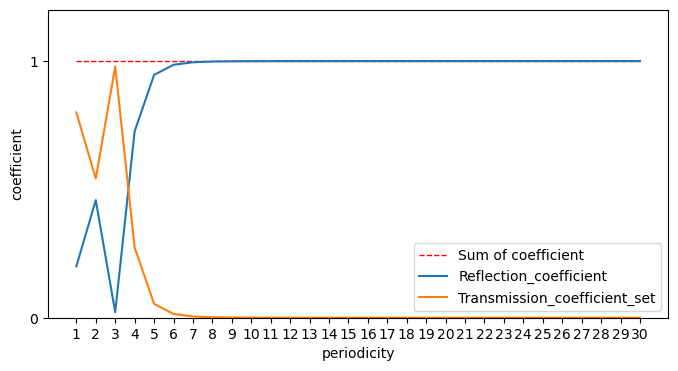

1.0000000000000007


In [27]:
import matplotlib.pyplot as plt       #draw a diagram (The change of transmission coefficient and reflection coefficient with period number n)
def draw_a_diagram_1(n1,n2):
    Reflection_coefficient_set=np.zeros((n2),dtype=float)
    for i in np.arange(n1,n2+1):
        Reflection_coefficient_set[i-1]= Reflection_coefficient_of_N(i)
    Transmission_coefficient_set=np.zeros((n2),dtype=float)
    for i in np.arange(n1,n2+1):
        Transmission_coefficient_set[i-1]= Transmission_coefficient_of_N(i)
    x = np.arange(n1,n2+1,1)
    y1 = Reflection_coefficient_set
    y2 = Transmission_coefficient_set
    plt.figure(num=2, figsize=(8, 4))
    plt.plot(x, y1+y2, color='red', linewidth='1.0', linestyle='--',label='Sum of coefficient')
    plt.plot(x, y1,label='Reflection_coefficient')
    plt.plot(x, y2,label='Transmission_coefficient_set')
    plt.xlabel('periodicity')
    plt.ylabel('coefficient')
    new_ticks1 = np.linspace(1, n2, n2)
    new_ticks2 = np.linspace(0, 20, 21)
    plt.xticks(new_ticks1)
    plt.yticks(new_ticks2)
    plt.legend()
    plt.ylim(0, 1.2)
    plt.show()
draw_a_diagram_1(1,30)
print(Reflection_coefficient_of_N(30)+Transmission_coefficient_of_N(30))

In [6]:
#constant
y=1j
E=1
k=E**0.5
constant_1=2*m*y/(h1**2)
print(Transmission_coefficient_of_N(1),Reflection_coefficient_of_N(1))

4.0 0.9999999999999999


In [7]:
import matplotlib.pyplot as plt       #draw a diagram (The change of transmission coefficient and reflection coefficient with period number n)
def draw_a_diagram_2(n1,n2):
    Reflection_coefficient_set=np.zeros((n2-n1+1),dtype=float)
    for i in np.arange(n1,n2+1):
        Reflection_coefficient_set[i-n1]= Reflection_coefficient_of_N(i)
    Transmission_coefficient_set=np.zeros((n2-n1+1),dtype=float)
    for i in np.arange(n1,n2+1):
        Transmission_coefficient_set[i-n1]= Transmission_coefficient_of_N(i)
    x = np.arange(n1,n2+1,1)
    y1 = Reflection_coefficient_set
    y2 = Transmission_coefficient_set
    plt.figure(num=2, figsize=(8, 4))
    plt.plot(x, y1+y2, color='red', linewidth='1.0', linestyle='--',label='Sum of coefficient')
    plt.plot(x, y1,label='Reflection_coefficient')
    plt.plot(x, y2,label='Transmission_coefficient_set')
    plt.xlabel('imaginary potential number')
    plt.ylabel('coefficient')
    new_ticks1 = np.linspace(n1, n2, n2-n1+1)
    new_ticks2 = np.linspace(0, 6, 13)
    plt.xticks(new_ticks1)
    plt.yticks(new_ticks2)
    plt.legend()
    plt.ylim(0, 6)
    plt.show()
    print('Reflection_coefficient',Reflection_coefficient_set,'Transmission_coefficient',Transmission_coefficient_set)   
# Plus a first imaginary potential, plus a other imaginary potential 

1.0151626134615392 0.04548784038461821


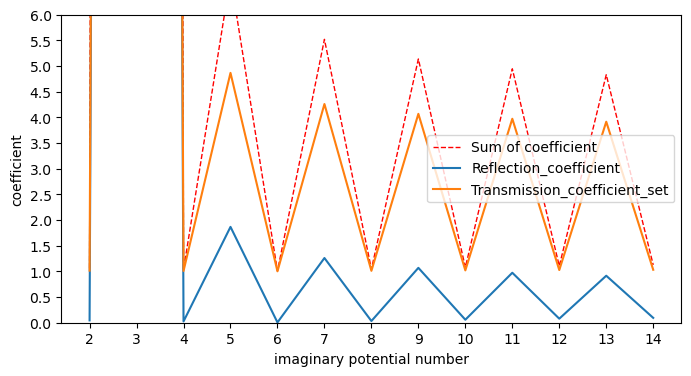

Reflection_coefficient [4.54878404e-02 1.97602870e+02 2.47867248e-02 1.86712870e+00
 5.68888142e-03 1.26021543e+00 3.31528965e-02 1.06887728e+00
 5.85724142e-02 9.73257998e-01 7.87570857e-02 9.15385747e-01
 9.46658835e-02] Transmission_coefficient [  1.01516261 200.60286974   1.00826224   4.8671287    1.00189629
   4.26021543   1.01105097   4.06887728   1.01952414   3.973258
   1.02625236   3.91538575   1.03155529]


In [8]:
#constant
y=1j
E=1
k=E**0.5
constant_1=2*m*y/(h1**2)
print(Transmission_coefficient_of_N(2),Reflection_coefficient_of_N(2))
draw_a_diagram_2(2,14)

1.0151626134615392 0.0050542044871798


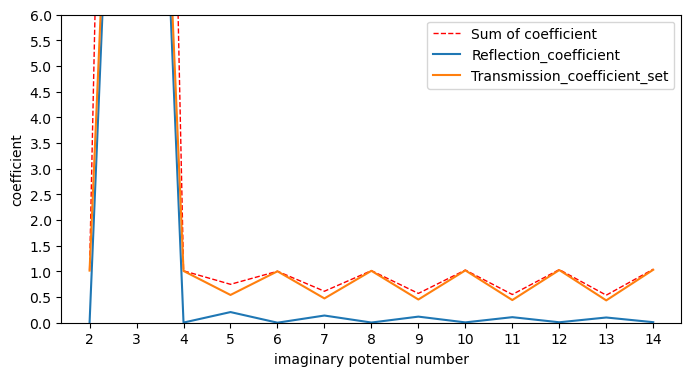

Reflection_coefficient [5.05420449e-03 2.19558744e+01 2.75408053e-03 2.07458745e-01
 6.32097936e-04 1.40023937e-01 3.68365517e-03 1.18764142e-01
 6.50804602e-03 1.08139778e-01 8.75078730e-03 1.01709527e-01
 1.05184315e-02] Transmission_coefficient [ 1.01516261 22.28920775  1.00826224  0.54079208  1.00189629  0.47335727
  1.01105097  0.45209748  1.01952414  0.44147311  1.02625236  0.43504286
  1.03155529]


In [9]:
#constant
y=-1j
E=1
k=E**0.5
constant_1=2*m*y/(h1**2)
print(Transmission_coefficient_of_N(2),Reflection_coefficient_of_N(2))
draw_a_diagram_2(2,14)

In [10]:
import numpy as np                                                        #  matrix coupling
def coupling(matrix_1,matrix_2):                                 
    s11_1=matrix_1[0][0]
    s12_1=matrix_1[0][1]
    s21_1=matrix_1[1][0]
    s22_1=matrix_1[1][1]
    s11_2=matrix_2[0][0]
    s12_2=matrix_2[0][1]
    s21_2=matrix_2[1][0]
    s22_2=matrix_2[1][1]
    s11=s11_1+s12_1*s21_1*s11_2/(1-s11_2*s22_1)
    s12=s12_1*s12_2/(1-s11_2*s22_1)
    s21=s21_2*s21_1/(1-s11_2*s22_1)
    s22=s22_2+s21_2*s12_2*s22_1/(1-s11_2*s22_1)
    result = np.array([[s11, s12], [s21, s22]], np.complex128)
    return result                                                   
def multiple_coupling(matrix_collect_1):                                  #  multiple_coupling
    matrix_collect_2= matrix_collect_1[0]
    for i in np.arange(len(matrix_collect_1)):
        if i==len(matrix_collect_1)-1:
            break
        matrix_collect_2=coupling(matrix_collect_2,matrix_collect_1[i+1])
    return matrix_collect_2
def coupling_matrix_of_N_modified(N,n3,n4):             #coupling_matrix_of_N    N is period  n3 is (Sum of Plus second potential)
    location = np.linspace(x_0, x_1, 2*N+n3+n4)          #n4 is (Sum of Plus first potential)
    di=np.zeros((2*N+n3+n4),dtype=complex)
    for i in np.arange(2*N+n3+n4):
        if i<(2*N):
            di[i]=constant_1*(-1)**(i)
        if i>=(2*N) and i<(2*N+n3):
            di[i]=constant_1
        if i>=(2*N+n3):
            di[i]=constant_1*(-1)
    matrix_collect = np.zeros((2*N+n3+n4, 2, 2), dtype=complex)
    for i in np.arange(2*N+n3+n4):
        s11=di[i]*np.exp((2j)*k*location[i])
        s12=2j*k
        s21=2j*k
        s22=di[i]*np.exp((-2j)*k*location[i])
        if i==len(np.arange(2*N+n3+n4))-1:
            s12=0
            s22=0
        matrix_3= np.array([[s11, s12], [s21, s22]])/(-di[i]+2j*k)
        matrix_collect[i]=matrix_3
    matrix_6 = multiple_coupling(matrix_collect)
  #  print(matrix_collect)
    return matrix_6
def Transmission_coefficient_of_N_modified(N,n3,n4):
    return float(abs(coupling_matrix_of_N_modified(N,n3,n4)[1][0]**2))
def Reflection_coefficient_of_N_modified(N,n3,n4):
    return float(abs(coupling_matrix_of_N_modified(N,n3,n4)[0][0]**2))

In [11]:
y=1j
E=1
k=E**0.5
constant_1=2*m*y/(h1**2)
print(Transmission_coefficient_of_N(6),Reflection_coefficient_of_N(6))
print(Transmission_coefficient_of_N_modified(1,2,2),Reflection_coefficient_of_N_modified(1,2,2))
print(Transmission_coefficient_of_N_modified(2,1,1),Reflection_coefficient_of_N_modified(2,1,1))
print(Transmission_coefficient_of_N(2),Reflection_coefficient_of_N(2))
print(Transmission_coefficient_of_N_modified(0,1,1),Reflection_coefficient_of_N_modified(0,1,1))

1.001896293807126 0.005688881421380589
2.360376597462526 20.8335417619907
1.001896293807126 0.005688881421380589
1.0151626134615392 0.04548784038461821
1.0151626134615392 0.04548784038461821


In [12]:
import matplotlib.pyplot as plt       #draw a diagram (The change of transmission coefficient and reflection coefficient with period number n)
def draw_a_diagram_3(n6,n7,n8,n9):
    Reflection_coefficient_set=np.zeros((n7+1),dtype=float)
    for i in np.arange(n7+1):
        if n9==1:
            Reflection_coefficient_set[i]=  Reflection_coefficient_of_N_modified(n6,i,0)
        if n9==-1:
            Reflection_coefficient_set[i]=  Reflection_coefficient_of_N_modified(n6,0,i)
    Transmission_coefficient_set=np.zeros((n7+1),dtype=float)
    for i in np.arange(n7+1):
        if n9>0:
            Transmission_coefficient_set[i]=  Transmission_coefficient_of_N_modified(n6,i,0)
        if n9<0:
            Transmission_coefficient_set[i]=  Transmission_coefficient_of_N_modified(n6,0,i)
    x = np.arange(n6,n6+n7+1,1)
    y1 = Reflection_coefficient_set
    y2 = Transmission_coefficient_set
    plt.figure(num=2, figsize=(8, 4))
    plt.plot(x, y1+y2, color='red', linewidth='1.0', linestyle='--',label='Sum of coefficient')
    plt.plot(x, y1,label='Reflection_coefficient')
    plt.plot(x, y2,label='Transmission_coefficient_set')
    plt.xlabel('imaginary potential number')
    plt.ylabel('coefficient')
    new_ticks1 = np.linspace(n6, n6+n7,n7+1)
    new_ticks2 = np.linspace(0, n8, 13)
    plt.xticks(new_ticks1)
    plt.yticks(new_ticks2)
    plt.legend()
    plt.ylim(0, n8)
    plt.show()
    print('Reflection_coefficient',Reflection_coefficient_set,'Transmission_coefficient',Transmission_coefficient_set,'Sum of coefficient',y1+y2)   
# Plus a first imaginary potential, plus a other imaginary potential 

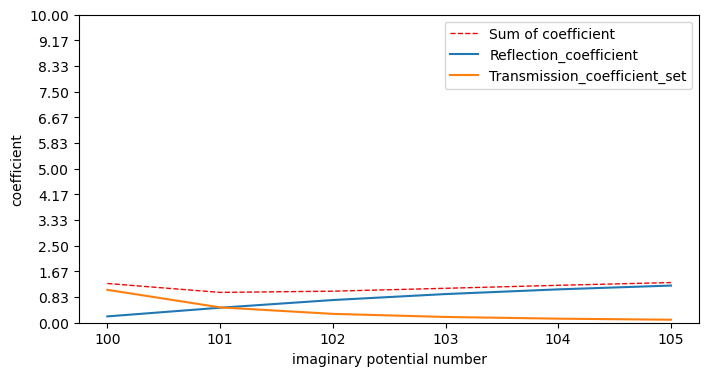

Reflection_coefficient [0.20515496 0.48661053 0.73675475 0.93056406 1.08299916 1.20658476] Transmission_coefficient [1.06838499 0.49808722 0.28741312 0.18707935 0.13152992 0.09753234] Sum of coefficient [1.27353994 0.98469774 1.02416788 1.11764341 1.21452908 1.3041171 ]


In [13]:
y=1j
E=1
k=E**0.5
constant_1=2*m*y/(h1**2)
draw_a_diagram_3(100,5,10,-1) 
#The first number is the total number of periods, the second is the number of points, 
#the third is the range of coefficients, and the fourth is the positive and negative of the potential points

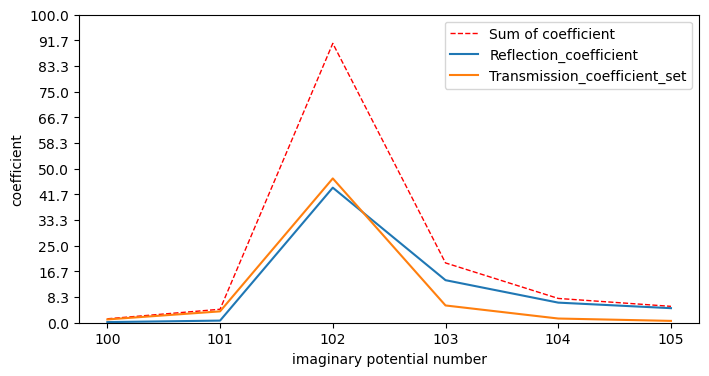

Reflection_coefficient [ 0.20515496  0.68559558 43.84876278 13.81168495  6.52427951  4.72409543] Transmission_coefficient [ 1.06838499  3.68559558 46.84876278  5.60471907  1.36103591  0.59437863] Sum of coefficient [ 1.27353994  4.37119115 90.69752556 19.41640401  7.88531543  5.31847406]


In [14]:
draw_a_diagram_3(100,5,100,1)

C:\Users\taoji\AppData\Local\Temp\ipykernel_2988\1528238693.py:43: RuntimeWarning: invalid value encountered in divide
  matrix_3= np.array([[s11, s12], [s21, s22]])/(-di[i]+2j*k)
C:\Users\taoji\AppData\Local\Temp\ipykernel_2988\1528238693.py:11: RuntimeWarning: invalid value encountered in scalar divide
  s11=s11_1+s12_1*s21_1*s11_2/(1-s11_2*s22_1)
C:\Users\taoji\AppData\Local\Temp\ipykernel_2988\1528238693.py:12: RuntimeWarning: invalid value encountered in scalar divide
  s12=s12_1*s12_2/(1-s11_2*s22_1)
C:\Users\taoji\AppData\Local\Temp\ipykernel_2988\1528238693.py:13: RuntimeWarning: invalid value encountered in scalar divide
  s21=s21_2*s21_1/(1-s11_2*s22_1)
C:\Users\taoji\AppData\Local\Temp\ipykernel_2988\1528238693.py:14: RuntimeWarning: invalid value encountered in scalar divide
  s22=s22_2+s21_2*s12_2*s22_1/(1-s11_2*s22_1)


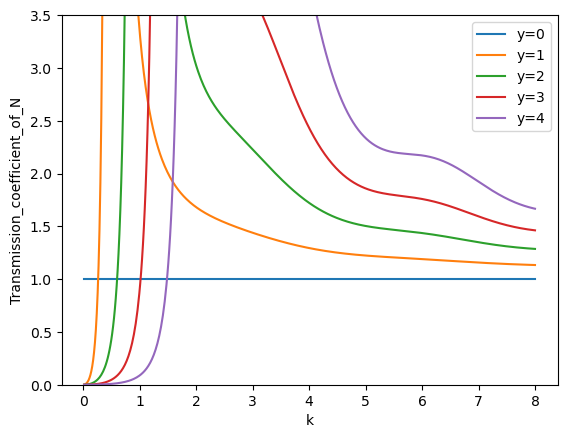

In [15]:
m=0.5                                   
h1=1
x_0=-0.5
x_1=0.5
n=50
k_set=np.linspace(0,8,500)                                        
y_all_set=np.zeros((5,len(k_set)),dtype=float)
for i in np.arange(5):
    y1=i*1j
    constant_1=2*m*y1/(h1**2) 
    y_set=np.zeros((len(k_set)),dtype=float)
    for j in np.arange(len(k_set)):
        k=k_set[j]
        y_set[j]=Transmission_coefficient_of_N_modified(n,1,0)
    y_all_set[i]=y_set
for i in np.arange(5):
    plt.plot(k_set, y_all_set[i],label=f'y={i}')
new_ticks1 = np.linspace(0, 8,9)
new_ticks2 = np.linspace(0,3.5,8)
plt.xlabel('k')
plt.ylabel('Transmission_coefficient_of_N')
plt.xticks(new_ticks1)
plt.yticks(new_ticks2)
plt.ylim(0, 3.5)
plt.legend()
plt.show()

C:\Users\taoji\AppData\Local\Temp\ipykernel_2988\853740097.py:15: RuntimeWarning: invalid value encountered in divide
  matrix_3= np.array([[s11, s12], [s21, s22]])/(-di[i]+2j*k)
C:\Users\taoji\AppData\Local\Temp\ipykernel_2988\1528238693.py:11: RuntimeWarning: invalid value encountered in scalar divide
  s11=s11_1+s12_1*s21_1*s11_2/(1-s11_2*s22_1)
C:\Users\taoji\AppData\Local\Temp\ipykernel_2988\1528238693.py:12: RuntimeWarning: invalid value encountered in scalar divide
  s12=s12_1*s12_2/(1-s11_2*s22_1)
C:\Users\taoji\AppData\Local\Temp\ipykernel_2988\1528238693.py:13: RuntimeWarning: invalid value encountered in scalar divide
  s21=s21_2*s21_1/(1-s11_2*s22_1)
C:\Users\taoji\AppData\Local\Temp\ipykernel_2988\1528238693.py:14: RuntimeWarning: invalid value encountered in scalar divide
  s22=s22_2+s21_2*s12_2*s22_1/(1-s11_2*s22_1)


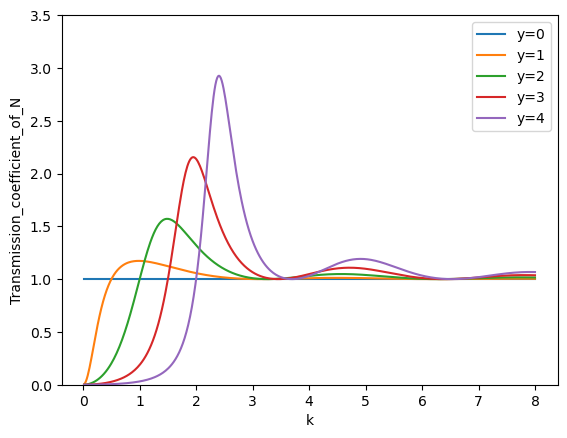

In [16]:
m=0.5                                   
h1=1
x_0=-0.5
x_1=0.5
n=100
k_set=np.linspace(0,8,500)                                        
y_all_set=np.zeros((5,len(k_set)),dtype=float)
for i in np.arange(5):
    y1=1*i*1j
    constant_1=2*m*y1/(h1**2) 
    y_set=np.zeros((len(k_set)),dtype=float)
    for j in np.arange(len(k_set)):
        k=k_set[j]
        y_set[j]=Transmission_coefficient_of_N(n)
    y_all_set[i]=y_set
for i in np.arange(5):
    plt.plot(k_set, y_all_set[i],label=f'y={i}')
new_ticks1 = np.linspace(0, 8,9)
new_ticks2 = np.linspace(0,3.5,8)
plt.xlabel('k')
plt.ylabel('Transmission_coefficient_of_N')
plt.xticks(new_ticks1)
plt.yticks(new_ticks2)
plt.ylim(0, 3.5)
plt.legend()
plt.show()